# BERT4Rec — Feature-Aware with User Context
### Improvements over v1
- **User feature fusion**: user behavioural + genre-preference vectors injected at the sequence level
- **Sparse-safe user encoder**: drops near-zero genre cols, applies StandardScaler, projects to hidden dim
- **Cosine annealing LR schedule** with warm restarts (replaces flat LR)
- **Gradient clipping** to stabilise training
- **`mask_ratio` = 0.2** (down from 0.4) — empirically better for moderate-length sequences
- **Larger hidden dim (128) and 4 attention heads** for more expressive representations
- **Weighted loss** — upweights rare items to counter popularity bias
- **Cleaner evaluation**: one function, returns all K in one pass


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports & Config

In [ ]:
import os, random, math, json
from collections import OrderedDict

import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from torch.nn.functional import cosine_similarity
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
# ── Mount Drive (Colab only) ──────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
    print('Google Drive mounted.')
except Exception:
    DRIVE_ROOT = '.'
    print('Not in Colab — using local directory.')


Mounted at /content/drive
Google Drive mounted.


In [ ]:
notebook_config = {
    'random_seed':            42,
    'model_train_flg':        True,
    'model_train_resume_flg': False,
    'model_save_path':        './bert4rec_v2.pth',
    'model_load_path':        './bert4rec_v2.pth',
}

vocab_config = {
    'padding_index': 0,
    'mask_index':    1,
}

train_config = {
    'batch_size':           256,
    'mask_ratio':           0.20,      # ↓ from 0.40 — better for seq len ≤50
    'num_epochs':           200,
    'additional_epochs':    40,
    'lr':                   1e-3,
    'lr_resume':            1e-4,
    'optimizer_betas':      (0.9, 0.999),
    'weight_decay':         0.01,
    'grad_clip':            1.0,       # NEW: gradient clipping
    'warmup_steps':         500,       # NEW: linear warmup before cosine decay
}

model_config = {
    'hidden_dims':              128,   # ↑ from 64
    'num_attention_heads':      4,     # ↑ from 2
    'num_hidden_layers':        2,
    'intermediate_dims':        512,   # ↑ proportionally
    'max_sentence_length':      50,
    'vocab_size':               0,     # set after loading data
    'user_feature_dim':         0,     # set after loading user features
    'hidden_dropout_prob':      0.1,
    'attention_dropout_prob':   0.1,
    'classifier_dropout_prob':  0.1,
    'initializer_std':          0.01,
    'initializer_range':        0.02,
    'eps':                      1e-12,
}

# Reproducibility
np.random.seed(notebook_config['random_seed'])
random.seed(notebook_config['random_seed'])
torch.manual_seed(notebook_config['random_seed'])
torch.cuda.manual_seed_all(notebook_config['random_seed'])
print('Seeds set.')


Seeds set.


## 2. Data Loading & Preprocessing

In [ ]:
INTERACTIONS_PATH  = os.path.join(DRIVE_ROOT, 'data2.csv')
ITEM_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'item_features2.csv')
USER_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'user_features2.csv')


In [ ]:
# ── Item features ──────────────────────────────────────────────────────────────
item_features_pd = (
    pd.read_csv(ITEM_FEATURES_PATH)
      .sort_values('item_idx')
      .reset_index(drop=True)
)

item_lookup_df = (
    item_features_pd[['item_idx', 'item_id']]
      .set_index('item_idx')
)

print(f'Items loaded : {len(item_features_pd):,}')


Items loaded : 8,411


In [ ]:
def build_item_feature_matrix(df: pd.DataFrame):
    """
    Numeric + genre features, one-hot language.
    Rows 0/1 = PAD/MASK sentinels; real items start at row 2.
    """
    ignore = {'item_idx', 'item_id', 'title', 'genres_raw', 'release_date_raw'}
    num_cols = [
        c for c in df.columns
        if c not in ignore | {'original_language'}
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    lang_dummies = pd.get_dummies(
        df['original_language'].fillna('unknown').astype(str), prefix='lang'
    )
    feature_df = pd.concat(
        [df[num_cols].fillna(0), lang_dummies], axis=1
    ).fillna(0)

    # Standardise numeric columns (not binary genre/lang cols)
    binary_cols = set(c for c in feature_df.columns if feature_df[c].nunique() <= 2)
    scale_cols  = [c for c in feature_df.columns if c not in binary_cols]
    if scale_cols:
        scaler = StandardScaler()
        feature_df[scale_cols] = scaler.fit_transform(feature_df[scale_cols])

    arr = feature_df.to_numpy(dtype=np.float32)
    padded = np.zeros((len(df) + 2, arr.shape[1]), dtype=np.float32)
    padded[2:] = arr
    return torch.tensor(padded, dtype=torch.float32), feature_df.columns.tolist()


item_feature_tensor, item_feature_columns = build_item_feature_matrix(item_features_pd)
num_items = len(item_features_pd)
model_config['vocab_size'] = num_items + 2
print(f'Item feature matrix : {item_feature_tensor.shape}')
print(f'vocab_size          : {model_config["vocab_size"]}')


Item feature matrix : torch.Size([8413, 78])
vocab_size          : 8413


In [ ]:
# ── User features (sparse-safe) ───────────────────────────────────────────────
user_features_pd = (
    pd.read_csv(USER_FEATURES_PATH)
      .sort_values('user_idx')
      .reset_index(drop=True)
)

def build_user_feature_matrix(df: pd.DataFrame, sparsity_threshold: float = 0.95):
    """
    Build a user feature matrix, dropping near-constant sparse genre columns.

    Steps:
      1. Drop string/date columns and very sparse genre columns
         (zero-fraction >= sparsity_threshold).
      2. One-hot encode ordinal tier/bucket columns.
      3. StandardScale continuous columns.

    Returns (tensor [n_users, d], column_names).
    """
    drop_meta = {'user_idx', 'user_id', 'first_seen', 'last_seen'}
    ordinal   = {'user_engagement_tier', 'user_preferred_hour_bucket'}

    # Identify and drop near-zero sparse columns
    numeric_df = df.drop(columns=[c for c in drop_meta if c in df.columns], errors='ignore')
    num_only   = numeric_df.select_dtypes(include='number')
    zero_frac  = (num_only == 0).mean()
    sparse_cols = zero_frac[zero_frac >= sparsity_threshold].index.tolist()
    print(f'  Dropping {len(sparse_cols)} sparse columns (zero-frac >= {sparsity_threshold}):')
    print(f'  {sparse_cols[:8]}{"..." if len(sparse_cols) > 8 else ""}')

    keep_num = [
        c for c in num_only.columns
        if c not in sparse_cols and c not in ordinal
    ]

    parts = []
    if keep_num:
        sub = numeric_df[keep_num].fillna(0).copy()
        binary = [c for c in keep_num if sub[c].nunique() <= 2]
        cont   = [c for c in keep_num if c not in binary]
        if cont:
            scaler = StandardScaler()
            sub[cont] = scaler.fit_transform(sub[cont])
        parts.append(sub)

    for col in ordinal:
        if col in df.columns:
            dummies = pd.get_dummies(df[col].fillna(0).astype(int), prefix=col)
            parts.append(dummies)

    if not parts:
        raise ValueError('No usable user features found.')

    feature_df = pd.concat(parts, axis=1).fillna(0)
    arr = feature_df.to_numpy(dtype=np.float32)
    print(f'  User feature matrix : {arr.shape[0]:,} users x {arr.shape[1]} features')
    return torch.tensor(arr, dtype=torch.float32), feature_df.columns.tolist()


print('Building user feature matrix...')
user_feature_tensor, user_feature_columns = build_user_feature_matrix(user_features_pd)
model_config['user_feature_dim'] = user_feature_tensor.shape[1]
print(f'  user_feature_dim set to {model_config["user_feature_dim"]}')


Building user feature matrix...
  Dropping 9 sparse columns (zero-frac >= 0.95):
  ['user_pref_genre_film_noir', 'user_pref_genre_musical', 'user_pref_genre_news', 'user_pref_genre_reality_tv', 'user_pref_genre_science_fiction', 'user_pref_genre_short', 'user_pref_genre_talk_show', 'user_pref_genre_tv_movie']...
  User feature matrix : 161,619 users x 38 features
  user_feature_dim set to 38


In [ ]:
# ── Interactions ──────────────────────────────────────────────────────────────
print(f'Loading interactions...')
df = pl.read_csv(INTERACTIONS_PATH)
df = df.with_columns([
    pl.col('datetime').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False),
    (pl.col('item_idx') + 2).alias('item_token'),
])
print(f'  {len(df):,} rows, {df["user_id"].n_unique():,} unique users')

actual_vocab = int(df['item_token'].max()) + 1
assert actual_vocab == model_config['vocab_size'], (
    f'vocab mismatch: data={actual_vocab}, config={model_config["vocab_size"]}')

# Build user_idx → user_feature_tensor row mapping
user_id_to_idx = (
    user_features_pd[['user_idx', 'user_id']]
      .set_index('user_id')['user_idx']
      .to_dict()
)

# Build sorted sequences + track user indices
user_rows = (
    df.group_by(['user_id', 'user_idx'])
      .agg(
          pl.col('item_token').sort_by(pl.col('datetime')).alias('sequence')
      )
      .sort('user_idx')
)

sequences   = user_rows['sequence'].to_list()
user_indices = user_rows['user_idx'].to_list()
print(f'  Sequences built: {len(sequences):,}')

# Leave-one-out split
train_seqs, val_data, test_data = [], [], []
train_user_idx, val_user_idx, test_user_idx = [], [], []

for seq, uidx in zip(sequences, user_indices):
    if len(seq) < 3:
        continue
    train_seqs.append(seq[:-2]);  train_user_idx.append(uidx)
    val_data.append((seq[:-2], seq[-2]));   val_user_idx.append(uidx)
    test_data.append((seq[:-1], seq[-1]));  test_user_idx.append(uidx)

print(f'  Train: {len(train_seqs):,}  Val: {len(val_data):,}  Test: {len(test_data):,}')


Loading interactions...
  649,250 rows, 161,619 unique users
  Sequences built: 161,619
  Train: 72,138  Val: 72,138  Test: 72,138


In [ ]:
# ── Item popularity weights for loss ─────────────────────────────────────────
# Rare items get upweighted so the model doesn't just predict popular items.
item_counts = df['item_token'].value_counts().to_pandas().set_index('item_token')['count']
weight_vec  = np.ones(model_config['vocab_size'], dtype=np.float32)
for tok, cnt in item_counts.items():
    weight_vec[int(tok)] = 1.0 / (cnt ** 0.5)   # inverse-sqrt frequency
weight_vec[0] = 0.0   # PAD
weight_vec[1] = 0.0   # MASK
item_loss_weights = torch.tensor(weight_vec, dtype=torch.float32)
print(f'Loss weight vector built. Non-zero entries: {(item_loss_weights > 0).sum().item():,}')


Loss weight vector built. Non-zero entries: 8,411


## 3. Model Definition

### 3.1 Embedding (item + position + item-features)

In [ ]:
class BertEmbedding(nn.Module):
    def __init__(self, cfg, vcfg, item_feature_matrix):
        super().__init__()
        H = cfg['hidden_dims']
        self.seq_len = cfg['max_sentence_length']

        self.item_embedding     = nn.Embedding(cfg['vocab_size'], H,
                                               padding_idx=vcfg['padding_index'])
        self.position_embedding = nn.Embedding(cfg['max_sentence_length'], H)
        self.feature_projection = nn.Linear(item_feature_matrix.shape[1], H, bias=False)

        self.register_buffer('item_feature_matrix', item_feature_matrix)
        self.layer_norm = nn.LayerNorm(H, eps=cfg['eps'])
        self.dropout    = nn.Dropout(cfg['hidden_dropout_prob'])
        self._init_weights(cfg)

    def _init_weights(self, cfg):
        std, r = cfg['initializer_std'], cfg['initializer_range']
        for p in [self.item_embedding.weight, self.position_embedding.weight,
                  self.feature_projection.weight]:
            init.trunc_normal_(p, mean=0.0, std=std, a=-r, b=r)
        init.ones_(self.layer_norm.weight)
        init.zeros_(self.layer_norm.bias)

    def forward(self, input_ids):
        B, L = input_ids.shape
        pos_ids = torch.arange(L, device=input_ids.device).unsqueeze(0)
        emb = (self.item_embedding(input_ids)
               + self.feature_projection(self.item_feature_matrix[input_ids])
               + self.position_embedding(pos_ids))
        return self.dropout(self.layer_norm(emb))


### 3.2 Transformer layers

In [ ]:
class TFAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H = cfg['hidden_dims']
        self.attn       = nn.MultiheadAttention(H, cfg['num_attention_heads'],
                                                dropout=cfg['attention_dropout_prob'],
                                                batch_first=True)
        self.drop       = nn.Dropout(cfg['hidden_dropout_prob'])
        self.norm       = nn.LayerNorm(H, eps=cfg['eps'])
        std, r = cfg['initializer_std'], cfg['initializer_range']
        for name, p in self.attn.named_parameters():
            if 'weight' in name: init.trunc_normal_(p, 0, std, -r, r)
            else:                init.zeros_(p)

    def forward(self, x, key_padding_mask):
        h, _ = self.attn(x, x, x, key_padding_mask=key_padding_mask)
        return self.norm(x + self.drop(h))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H, I = cfg['hidden_dims'], cfg['intermediate_dims']
        std, r = cfg['initializer_std'], cfg['initializer_range']
        self.fc1  = nn.Linear(H, I)
        self.fc2  = nn.Linear(I, H)
        self.drop = nn.Dropout(cfg['hidden_dropout_prob'])
        self.norm = nn.LayerNorm(H, eps=cfg['eps'])
        for w in [self.fc1.weight, self.fc2.weight]:
            init.trunc_normal_(w, 0, std, -r, r)
        for b in [self.fc1.bias, self.fc2.bias]:
            init.zeros_(b)

    def forward(self, x):
        return self.norm(x + self.drop(self.fc2(F.gelu(self.fc1(x)))))


class TransformerLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = TFAttention(cfg)
        self.ff   = FeedForward(cfg)

    def forward(self, x, mask):
        return self.ff(self.attn(x, mask))


class BertEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.ModuleList([TransformerLayer(cfg)
                                     for _ in range(cfg['num_hidden_layers'])])

    def forward(self, x, pad_mask):
        for layer in self.layers:
            x = layer(x, pad_mask)
        return x


### 3.3 User feature encoder

In [ ]:
class UserEncoder(nn.Module):
    """
    Projects the (sparse) user feature vector to the hidden dimension.
    Uses a 2-layer MLP with residual-style gating so sparse zeros don't
    dominate the representation.
    """
    def __init__(self, user_feat_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1  = nn.Linear(user_feat_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, hidden_dim)
        self.gate = nn.Linear(user_feat_dim, hidden_dim)   # sparse gating
        self.norm = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)
        init.xavier_uniform_(self.fc1.weight);  init.zeros_(self.fc1.bias)
        init.xavier_uniform_(self.fc2.weight);  init.zeros_(self.fc2.bias)
        init.xavier_uniform_(self.gate.weight); init.zeros_(self.gate.bias)

    def forward(self, user_feats):
        """user_feats: (B, user_feat_dim)  →  (B, 1, hidden_dim) for broadcast addition."""
        g = torch.sigmoid(self.gate(user_feats))          # (B, H)
        h = self.drop(F.gelu(self.fc1(user_feats)))       # (B, H)
        h = self.drop(self.fc2(h)) * g                    # gated
        return self.norm(h).unsqueeze(1)                  # (B, 1, H)


### 3.4 Full model

In [ ]:
class Bert4RecV2(nn.Module):
    """
    BERT4Rec with:
      - Item embedding + item-feature projection + position embedding
      - User feature fusion (added to every sequence position)
      - Masked-LM head for training
    """
    def __init__(self, cfg, vcfg, item_feature_matrix, user_feature_dim):
        super().__init__()
        H = cfg['hidden_dims']

        self.embedding    = BertEmbedding(cfg, vcfg, item_feature_matrix)
        self.user_encoder = UserEncoder(user_feature_dim, H,
                                        dropout=cfg['hidden_dropout_prob'])
        self.encoder      = BertEncoder(cfg)

        self.cls = nn.Sequential(
            nn.Linear(H, H),
            nn.GELU(),
            nn.LayerNorm(H, eps=cfg['eps']),
            nn.Dropout(cfg['classifier_dropout_prob']),
            nn.Linear(H, cfg['vocab_size']),
        )
        std, r = cfg['initializer_std'], cfg['initializer_range']
        for layer in self.cls:
            if isinstance(layer, nn.Linear):
                init.trunc_normal_(layer.weight, 0, std, -r, r)
                init.zeros_(layer.bias)

    def forward(self, input_ids, pad_mask, user_feats=None):
        x = self.embedding(input_ids)                     # (B, L, H)
        if user_feats is not None:
            x = x + self.user_encoder(user_feats)         # broadcast over seq
        hidden = self.encoder(x, pad_mask)                # (B, L, H)
        logits = self.cls(hidden)                         # (B, L, V)
        return logits, hidden


## 4. Dataset & DataLoader

In [ ]:
class BertDataset(Dataset):
    def __init__(self, sequences, user_indices, user_feature_tensor,
                 max_len, mask_id, pad_id, mask_prob=0.15):
        self.sequences           = sequences
        self.user_indices        = user_indices
        self.user_feature_tensor = user_feature_tensor
        self.max_len   = max_len
        self.mask_id   = mask_id
        self.pad_id    = pad_id
        self.mask_prob = mask_prob

    def __len__(self): return len(self.sequences)

    def __getitem__(self, idx):
        seq  = list(self.sequences[idx])
        uidx = self.user_indices[idx]

        # Mask tokens
        tokens, labels = [], []
        for item in seq:
            if item != self.pad_id and random.random() < self.mask_prob:
                tokens.append(self.mask_id); labels.append(item)
            else:
                tokens.append(item);         labels.append(-100)

        # Truncate + left-pad
        tokens = tokens[-self.max_len:];  labels = labels[-self.max_len:]
        pad_n  = self.max_len - len(tokens)
        tokens = [self.pad_id] * pad_n + tokens
        labels = [-100]        * pad_n + labels

        tokens_t   = torch.tensor(tokens, dtype=torch.long)
        labels_t   = torch.tensor(labels, dtype=torch.long)
        pad_mask_t = tokens_t.eq(self.pad_id)
        user_feat  = self.user_feature_tensor[uidx]

        return tokens_t, labels_t, pad_mask_t, user_feat


train_loader = DataLoader(
    BertDataset(train_seqs, train_user_idx, user_feature_tensor,
                model_config['max_sentence_length'],
                vocab_config['mask_index'], vocab_config['padding_index'],
                mask_prob=train_config['mask_ratio']),
    batch_size=train_config['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
print(f'Train loader ready. {len(train_loader)} batches/epoch.')


Train loader ready. 282 batches/epoch.


## 5. Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = Bert4RecV2(
    model_config, vocab_config,
    item_feature_tensor,
    model_config['user_feature_dim'],
).to(device)

item_loss_weights = item_loss_weights.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=train_config['lr'],
    betas=train_config['optimizer_betas'],
    weight_decay=train_config['weight_decay'],
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=1, eta_min=1e-5
)

start_epoch        = 0
batch_loss_history = []
epoch_loss_history = []


Device: cuda
Trainable parameters: 2,618,845


Training for 200 epochs.
  Epoch 1/200 | Batch 0/282 | Loss 9.0450 | LR 1.00e-03
  Epoch 1/200 | Batch 100/282 | Loss 8.4324 | LR 1.00e-03
  Epoch 1/200 | Batch 200/282 | Loss 8.0149 | LR 1.00e-03
Epoch 1 done. Avg loss: 8.4265
  Epoch 2/200 | Batch 0/282 | Loss 8.0739 | LR 9.99e-04
  Epoch 2/200 | Batch 100/282 | Loss 7.7157 | LR 9.99e-04
  Epoch 2/200 | Batch 200/282 | Loss 7.6109 | LR 9.99e-04
Epoch 2 done. Avg loss: 7.8063
  Epoch 3/200 | Batch 0/282 | Loss 7.5364 | LR 9.96e-04
  Epoch 3/200 | Batch 100/282 | Loss 7.5446 | LR 9.96e-04
  Epoch 3/200 | Batch 200/282 | Loss 7.6903 | LR 9.96e-04
Epoch 3 done. Avg loss: 7.4218
  Epoch 4/200 | Batch 0/282 | Loss 7.1611 | LR 9.91e-04
  Epoch 4/200 | Batch 100/282 | Loss 7.2943 | LR 9.91e-04
  Epoch 4/200 | Batch 200/282 | Loss 7.1162 | LR 9.91e-04
Epoch 4 done. Avg loss: 7.0392
  Epoch 5/200 | Batch 0/282 | Loss 6.8530 | LR 9.84e-04
  Epoch 5/200 | Batch 100/282 | Loss 6.7093 | LR 9.84e-04
  Epoch 5/200 | Batch 200/282 | Loss 6.7297 | LR 

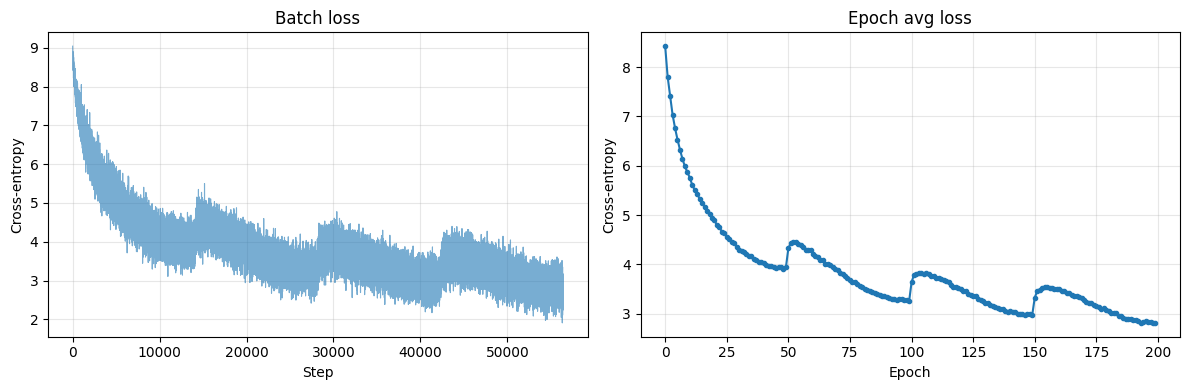

In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────────
if notebook_config['model_train_flg']:
    if notebook_config['model_train_resume_flg'] and os.path.exists(notebook_config['model_load_path']):
        ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor): state[k] = v.to(device)
        start_epoch = ckpt['epoch'] + 1
        num_epochs  = start_epoch + train_config['additional_epochs']
        for g in optimizer.param_groups: g['lr'] = train_config['lr_resume']
        print(f'Resuming from epoch {start_epoch}')
    else:
        num_epochs = train_config['num_epochs']
        print(f'Training for {num_epochs} epochs.')

    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0
        for i, (seq_b, lbl_b, pad_b, usr_b) in enumerate(train_loader):
            seq_b = seq_b.to(device)
            lbl_b = lbl_b.to(device)
            pad_b = pad_b.to(device)
            usr_b = usr_b.to(device)

            logits, _ = model(seq_b, pad_b, usr_b)

            loss = F.cross_entropy(
                logits.view(-1, model_config['vocab_size']),
                lbl_b.view(-1),
                ignore_index=-100,
                weight=item_loss_weights,   # popularity-debiased
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), train_config['grad_clip'])
            optimizer.step()

            batch_loss_history.append(loss.item())
            epoch_loss += loss.item()

            if i % 100 == 0:
                print(f'  Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(train_loader)} | Loss {loss.item():.4f} | LR {scheduler.get_last_lr()[0]:.2e}')

        scheduler.step()
        avg = epoch_loss / len(train_loader)
        epoch_loss_history.append(avg)
        print(f'Epoch {epoch+1} done. Avg loss: {avg:.4f}')

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg,
        }, notebook_config['model_save_path'])

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
    ax1.set(title='Batch loss', xlabel='Step', ylabel='Cross-entropy')
    ax1.grid(True, alpha=0.3)
    ax2.plot(epoch_loss_history, marker='o', markersize=3)
    ax2.set(title='Epoch avg loss', xlabel='Epoch', ylabel='Cross-entropy')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_loss_v2.png', dpi=120)
    plt.show()

else:
    ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print('Pre-trained model loaded.')


## 6. Evaluation

In [ ]:
def prepare_inference_input(history, user_feat, cfg, vcfg, device):
    """
    Append MASK at the end, left-pad to max_len.
    Returns (padded_tensor, pad_mask_tensor, user_feat_tensor).
    """
    max_len  = cfg['max_sentence_length']
    mask_idx = vcfg['mask_index']
    pad_idx  = vcfg['padding_index']

    seq = list(history)
    if len(seq) >= max_len:
        seq = seq[-(max_len - 1):]
    seq_with_mask = seq + [mask_idx]
    pad_n = max_len - len(seq_with_mask)
    padded   = [pad_idx] * pad_n + seq_with_mask
    pad_mask = [True]    * pad_n + [False] * len(seq_with_mask)

    return (
        torch.tensor(padded,   dtype=torch.long).unsqueeze(0).to(device),
        torch.tensor(pad_mask, dtype=torch.bool).unsqueeze(0).to(device),
        user_feat.unsqueeze(0).to(device),
    )


def evaluate_all_k(model, eval_data, user_indices, user_feature_tensor,
                   cfg, vcfg, device, k_list=(5, 10, 20)):
    """Single-pass evaluation for multiple K values."""
    model.eval()
    K_max = max(k_list)
    hits  = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}

    with torch.no_grad():
        for (history, target), uidx in zip(eval_data, user_indices):
            user_feat = user_feature_tensor[uidx]
            padded, pad_mask, usr = prepare_inference_input(
                history, user_feat, cfg, vcfg, device)

            logits, _ = model(padded, pad_mask, usr)
            scores = logits[0, -1].clone()
            scores[vcfg['padding_index']] = -1e9
            scores[vcfg['mask_index']]    = -1e9
            for item in history:
                scores[item] = -1e9

            ranked = torch.argsort(scores, descending=True).tolist()

            for k in k_list:
                if target in ranked[:k]:
                    rank = ranked.index(target) + 1
                    hits[k].append(1.0)
                    ndcgs[k].append(1.0 / math.log2(rank + 1))
                else:
                    hits[k].append(0.0)
                    ndcgs[k].append(0.0)

    return {
        k: {f'HR@{k}':   round(float(np.mean(hits[k])),  4),
            f'NDCG@{k}': round(float(np.mean(ndcgs[k])), 4)}
        for k in k_list
    }


In [ ]:
print('Validation')
val_metrics = evaluate_all_k(
    model, val_data, val_user_idx, user_feature_tensor,
    model_config, vocab_config, device)
for k, m in val_metrics.items():
    print(f'  {m}')

print('\nTest')
test_metrics = evaluate_all_k(
    model, test_data, test_user_idx, user_feature_tensor,
    model_config, vocab_config, device)
for k, m in test_metrics.items():
    print(f'  {m}')


Validation
  {'HR@5': 0.2626, 'NDCG@5': 0.2003}
  {'HR@10': 0.325, 'NDCG@10': 0.2204}
  {'HR@20': 0.3903, 'NDCG@20': 0.237}

Test
  {'HR@5': 0.2479, 'NDCG@5': 0.1886}
  {'HR@10': 0.3085, 'NDCG@10': 0.2081}
  {'HR@20': 0.372, 'NDCG@20': 0.2242}


## 7. Inference & Recommendation

In [ ]:
def get_item_name(tok, item_lookup_df, vcfg):
    if tok == vcfg['padding_index']: return f'<PAD {tok}>'
    if tok == vcfg['mask_index']:    return f'<MASK {tok}>'
    idx = int(tok) - 2
    return item_lookup_df.loc[idx, 'item_id'] if idx in item_lookup_df.index else f'unk_{tok}'


def recommend(history, user_idx, model, item_lookup_df, user_feature_tensor,
              vcfg, cfg, device, k=10, exclude_history=True):
    model.eval()
    user_feat = user_feature_tensor[user_idx]
    padded, pad_mask, usr = prepare_inference_input(history, user_feat, cfg, vcfg, device)

    with torch.no_grad():
        logits, _ = model(padded, pad_mask, usr)

    scores = logits[0, -1].clone()
    scores[vcfg['padding_index']] = -1e9
    scores[vcfg['mask_index']]    = -1e9
    if exclude_history:
        for item in history: scores[item] = -1e9

    probs = torch.softmax(scores, dim=0)
    top_v, top_i = torch.topk(probs, k=k)

    topk = OrderedDict(
        (get_item_name(i.item(), item_lookup_df, vcfg), round(p.item(), 6))
        for i, p in zip(top_i, top_v)
    )
    sampled_i = torch.multinomial(probs, num_samples=k, replacement=False)
    sampled   = OrderedDict(
        (get_item_name(i.item(), item_lookup_df, vcfg), round(probs[i].item(), 6))
        for i in sampled_i
    )
    return {'topk': topk, 'sampled': sampled, 'probs': probs}


In [ ]:
# Demo
sample_history, sample_target = val_data[0]
sample_uidx = val_user_idx[0]

print(f'User idx           : {sample_uidx}')
print(f'History length     : {len(sample_history)} items')
print(f'True next item     : {get_item_name(sample_target, item_lookup_df, vocab_config)}')

results = recommend(sample_history, sample_uidx, model, item_lookup_df,
                    user_feature_tensor, vocab_config, model_config, device)

print('\nTop-10 (deterministic):')
for name, p in results['topk'].items():
    marker = ' ← TRUE' if get_item_name(sample_target, item_lookup_df, vocab_config) == name else ''
    print(f'  {name:<30}  p={p:.6f}{marker}')

print('\nTop-10 (sampled):')
for name, p in results['sampled'].items():
    print(f'  {name:<30}  p={p:.6f}')


User idx           : 1
History length     : 22 items
True next item     : d601124c11

Top-10 (deterministic):
  a8df8dd2f3                      p=0.273110
  0c9155a262                      p=0.107056
  b264b980a6                      p=0.033324
  bad0e2356a                      p=0.030466
  b930391bf7                      p=0.014299
  83c3af610c                      p=0.013521
  5a43ef4772                      p=0.013463
  73183024a6                      p=0.012387
  4513e1694d                      p=0.011408
  f5f284408b                      p=0.010693

Top-10 (sampled):
  a8df8dd2f3                      p=0.273110
  0f30c4ebd3                      p=0.003465
  5f014c5f21                      p=0.000031
  4513e1694d                      p=0.011408
  83c3af610c                      p=0.013521
  65be88d027                      p=0.000495
  73183024a6                      p=0.012387
  0c9155a262                      p=0.107056
  b264b980a6                      p=0.033324
  03bdab04b5    

## 8. Item-Embedding Similarity

In [ ]:
def get_similar_items(query_token, model, item_lookup_df, vcfg, k=10):
    with torch.no_grad():
        base = model.embedding.item_embedding.weight.detach().cpu()
        feat = model.embedding.feature_projection(
                   model.embedding.item_feature_matrix).detach().cpu()
        combined = base + feat   # (V, H)

    q   = combined[query_token]
    sims = cosine_similarity(q.unsqueeze(0), combined[2:], dim=1)
    top_sims, top_idx = torch.topk(sims, k + 1)

    results = []
    for idx, score in zip(top_idx.tolist(), top_sims.tolist()):
        tok = idx + 2
        if tok == query_token: continue
        results.append((get_item_name(tok, item_lookup_df, vcfg), round(score, 4)))
        if len(results) == k: break
    return {'query': get_item_name(query_token, item_lookup_df, vcfg), 'similar': results}


query_tok   = val_data[0][0][0]
sim_results = get_similar_items(query_tok, model, item_lookup_df, vocab_config)
print(f'Similar to: {sim_results["query"]}')
for name, score in sim_results['similar']:
    print(f'  {name:<30}  cos_sim={score:.4f}')

print('\n✓ Pipeline complete.')


Similar to: 7314699c23
  0319e3220c                      cos_sim=0.4856
  ed635f875b                      cos_sim=0.4638
  604727e362                      cos_sim=0.4469
  bb1b21a139                      cos_sim=0.4277
  e71e44f18a                      cos_sim=0.4004
  a2d929e113                      cos_sim=0.3871
  adf1f45a1c                      cos_sim=0.3862
  65be88d027                      cos_sim=0.3823
  b9bf69fd52                      cos_sim=0.3757
  c12dbf31aa                      cos_sim=0.3755

✓ Pipeline complete.


In [ ]:
def evaluate_all_k(model, eval_data, user_indices, user_feature_tensor,
                   cfg, vcfg, device, k_list=(5, 10, 20)):
    model.eval()
    K_max = max(k_list)
    hits  = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}
    rr    = []   # for MRR

    with torch.no_grad():
        for (history, target), uidx in zip(eval_data, user_indices):
            user_feat = user_feature_tensor[uidx]
            padded, pad_mask, usr = prepare_inference_input(
                history, user_feat, cfg, vcfg, device)

            logits, _ = model(padded, pad_mask, usr)
            scores = logits[0, -1].clone()
            scores[vcfg['padding_index']] = -1e9
            scores[vcfg['mask_index']]    = -1e9
            for item in history:
                scores[item] = -1e9

            ranked = torch.argsort(scores, descending=True).tolist()

            # MRR (full ranking)
            if target in ranked:
                rr.append(1.0 / (ranked.index(target) + 1))
            else:
                rr.append(0.0)

            # HR + NDCG at each K
            for k in k_list:
                if target in ranked[:k]:
                    rank = ranked.index(target) + 1
                    hits[k].append(1.0)
                    ndcgs[k].append(1.0 / math.log2(rank + 1))
                else:
                    hits[k].append(0.0)
                    ndcgs[k].append(0.0)

    results = {
        k: {f'HR@{k}':   round(float(np.mean(hits[k])),  4),
            f'NDCG@{k}': round(float(np.mean(ndcgs[k])), 4)}
        for k in k_list
    }
    results['MRR'] = {'MRR': round(float(np.mean(rr)), 4)}
    return results


# ── Output ────────────────────────────────────────────────────────────────────
print('Validation')
val_metrics = evaluate_all_k(model, val_data, val_user_idx, user_feature_tensor,
                              model_config, vocab_config, device)
for k, m in val_metrics.items():
    print(f'  {m}')

print('\nTest')
test_metrics = evaluate_all_k(model, test_data, test_user_idx, user_feature_tensor,
                               model_config, vocab_config, device)
for k, m in test_metrics.items():
    print(f'  {m}')

Validation
  {'HR@5': 0.2626, 'NDCG@5': 0.2003}
  {'HR@10': 0.325, 'NDCG@10': 0.2204}
  {'HR@20': 0.3903, 'NDCG@20': 0.237}
  {'MRR': 0.1966}

Test
  {'HR@5': 0.2479, 'NDCG@5': 0.1886}
  {'HR@10': 0.3085, 'NDCG@10': 0.2081}
  {'HR@20': 0.372, 'NDCG@20': 0.2242}
  {'MRR': 0.1855}
